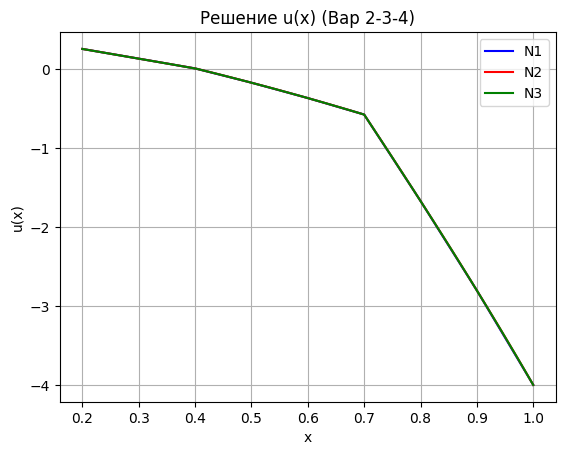

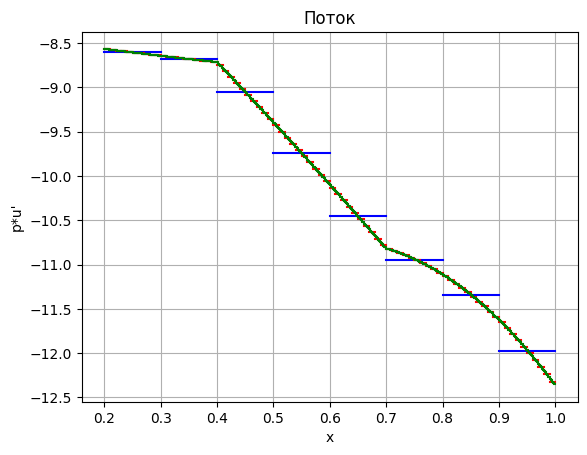

Невязка N=8: 0.03960535609194693 Шаг: 0.1
Невязка N=80: 0.004080042290949493 Шаг: 0.01
Невязка N=800: 0.000409228955623675 Шаг: 0.001


In [1]:
import numpy as np
import matplotlib.pyplot as plt

#Вар 2 . 1
a = 0.2
b = 1.0

def gal(N):
    #Вар 3 . 2
    p1, p2, p3 = 7.0, 5.0, 1.0
    q1, q2, q3 = 0.0, 1.0, 2.0

    #Вар 4. 3
    # Левый конец: 
    K_a = 4.0
    U_ca = 2.4

    U_b = -4.0

    h = round((b - a) / N, 10)

    def p(x):
        if a <= x < 0.4: # 2.1
            return p1
        elif 0.4 <= x < 0.7: # 2.1
            return p2
        else:
            return p3

    def q(x):
        if a <= x < 0.4:
            return q1
        elif 0.4 <= x < 0.7:
            return q2
        else:
            return q3

    def f(x):
        #2.1
        if a <= x < 0.4:
            return np.exp(-x)
        elif 0.4 <= x < 0.7:
            return 4 + np.sqrt(7 + x)
        else:
            return np.exp(-0.5 * x)

    x = a + np.arange(N + 1) * h

    def e_i(xv, X, i):
        if xv < X[i - 1]:
            return 0
        elif X[i - 1] <= xv < X[i]:
            return (xv - X[i - 1]) / h
        elif X[i] <= xv < X[i + 1]:
            return (X[i + 1] - xv) / h
        else:
            return 0

    def e_left(xv, X):
        if X[0] <= xv <= X[1]:
            return (X[1] - xv) / h
        else:
            return 0

    def f_e_i(xv, X, i):
        return f(xv) * e_i(xv, X, i)

    def f_e_left(xv, X):
        return f(xv) * e_left(xv, X)

    def gauss(func, a_, b_, X, j):
        nodes = np.array([-np.sqrt(1/3), np.sqrt(1/3)])
        weights = np.array([1, 1])
        nodes = 0.5*(b_-a_)*nodes + 0.5*(a_+b_)
        weights = 0.5*(b_-a_)*weights
        y = np.array([func(nodes[0], X, j), func(nodes[1], X, j)])
        return np.sum(weights*y)

    K = np.zeros((N+1, N+1))
    M = np.zeros((N+1, N+1))
    F = np.zeros(N+1)


    for j in range(1, N):
        K[j, j-1] = -p(x[j-1]) / h
        K[j, j] = (p(x[j-1]) + p(x[j])) / h
        K[j, j+1] = -p(x[j]) / h

        M[j, j-1] = q(x[j-1]) * h / 6
        M[j, j] = h * (q(x[j-1]) + q(x[j])) / 3
        M[j, j+1] = q(x[j]) * h / 6

        F[j] = gauss(f_e_i, x[j-1], x[j], x, j) + gauss(f_e_i, x[j], x[j+1], x, j)
    
    # Ka(u - Uc) = p*u'
    K[0,0] = p(x[0]) / h + K_a
    K[0,1] = -p(x[0]) / h
    M[0,0] = q(x[0]) * h / 3
    M[0,1] = q(x[0]) * h / 6
    F[0] = gauss(lambda xv, X, j: f_e_left(xv, X), x[0], x[1], x, 1) + K_a * U_ca

        # u = Ub
    K[N,N] = 1
    K[N,N-1] = 0  
    M[N,N] = 0
    M[N,N-1] = 0
    F[N] = U_b

    A_mat = K + M
    alpha = np.zeros(N+1)
    beta = np.zeros(N+1)

    alpha[0] = -A_mat[0,1] / A_mat[0,0]
    beta[0] = F[0] / A_mat[0,0]

    for k in range(1, N):
        a_k = A_mat[k, k-1]
        b_k = A_mat[k, k]
        c_k = A_mat[k, k+1]
        divis = a_k * alpha[k-1] + b_k
        alpha[k] = -c_k / divis
        beta[k] = (F[k] - a_k * beta[k-1]) / divis

    u = np.zeros(N+1)
    u[N] = F[N] 
    for i in range(N-1, -1, -1):
        u[i] = alpha[i]*u[i+1] + beta[i]

    d_u = np.zeros(N)
    p_d_u = np.zeros(N)
    for n in range(N):
        d_u[n] = (u[n+1] - u[n]) / h 
        p_d_u[n] = p(x[n]) * d_u[n] 

  
    nev = abs(K_a * (u[0] - U_ca) - p_d_u[0])

    return x, u, p_d_u, nev, h

x, u, pdu, nev, h = gal(8) 
x2, u2, pdu2, nev2, h2 = gal(80)
x3, u3, pdu3, nev3, h3 = gal(800)

colors = ['blue', 'red', 'green']
plt.figure()
plt.plot(x, u, label=f"N1", color = colors[0])
plt.plot(x2, u2, label=f"N2", color = colors[1])
plt.plot(x3, u3, label=f"N3", color = colors[2])
plt.xlabel("x") ; plt.ylabel("u(x)") ; plt.title("Решение u(x) (Вар 2-3-4)")
plt.grid() ; plt.legend()

plt.figure()
for i in range(len(pdu)):
    plt.plot([x[i], x[i+1]], [pdu[i], pdu[i]], color = colors[0])
for i in range(len(pdu2)):
    plt.plot([x2[i], x2[i+1]], [pdu2[i], pdu2[i]], color = colors[1])
for i in range(len(pdu3)):
    plt.plot([x3[i], x3[i+1]], [pdu3[i], pdu3[i]], color = colors[2])

plt.xlabel("x") ; plt.ylabel("p*u'") ; plt.title("Поток")
plt.grid()
plt.show()

print("Невязка N=8:", nev, "Шаг:", h)
print("Невязка N=80:", nev2, "Шаг:", h2)
print("Невязка N=800:", nev3, "Шаг:", h3)